In [1]:
# Install libraries (if needed in Colab)
!pip install opencv-python matplotlib numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

Saving Illusion_dress.jpg to Illusion_dress (1).jpg


(np.float64(-0.5), np.float64(255.5), np.float64(388.5), np.float64(-0.5))

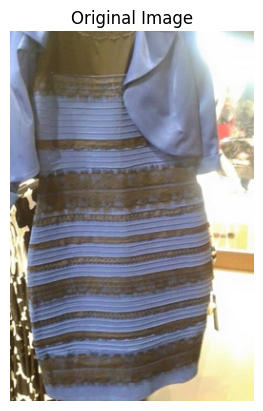

In [2]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
img = cv2.imread(image_path)

# Convert BGR to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")

In [3]:
h, w, _ = img_rgb.shape

# select center pixel
x = h // 2
y = w // 2

pixel_value = img_rgb[x, y]

print("Pixel Location:", (x,y))
print("RGB Value:", pixel_value)

Pixel Location: (194, 128)
RGB Value: [102  91  85]


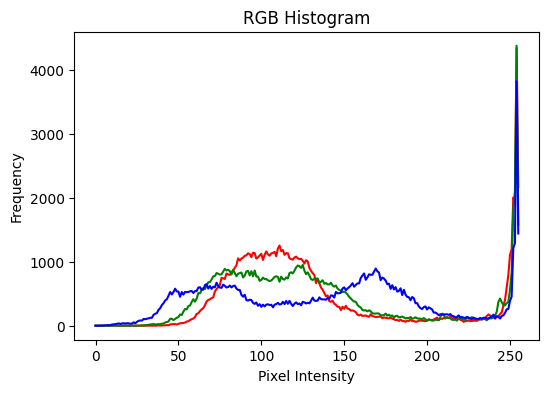

In [4]:
plt.figure(figsize=(6,4))

colors = ('r','g','b')

for i, color in enumerate(colors):
    hist = cv2.calcHist([img_rgb],[i],None,[256],[0,256])
    plt.plot(hist,color=color)

plt.title("RGB Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(388.5), np.float64(-0.5))

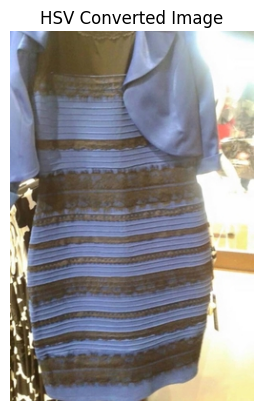

In [5]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.imshow(cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB))
plt.title("HSV Converted Image")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(388.5), np.float64(-0.5))

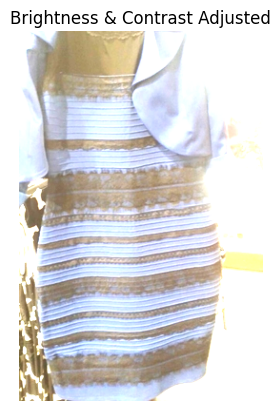

In [6]:
alpha = 1.5   # contrast
beta = 40     # brightness

adjusted = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

plt.imshow(cv2.cvtColor(adjusted, cv2.COLOR_BGR2RGB))
plt.title("Brightness & Contrast Adjusted")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(388.5), np.float64(-0.5))

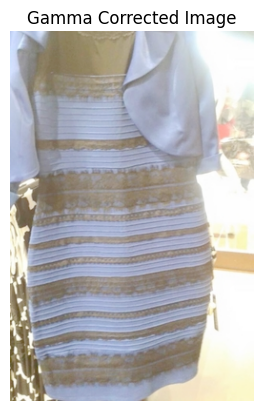

In [7]:
gamma = 1.8

invGamma = 1.0 / gamma
table = np.array([(i / 255.0) ** invGamma * 255
                  for i in np.arange(0,256)]).astype("uint8")

gamma_corrected = cv2.LUT(img, table)

plt.imshow(cv2.cvtColor(gamma_corrected, cv2.COLOR_BGR2RGB))
plt.title("Gamma Corrected Image")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(388.5), np.float64(-0.5))

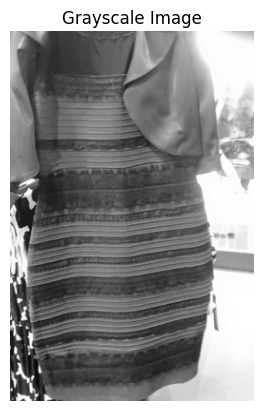

In [8]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(388.5), np.float64(-0.5))

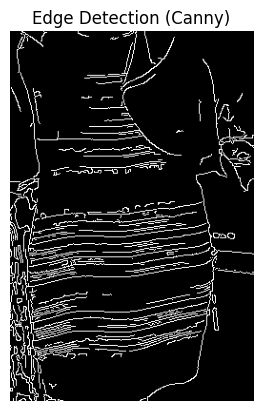

In [9]:
edges = cv2.Canny(gray,100,200)

plt.imshow(edges, cmap='gray')
plt.title("Edge Detection (Canny)")
plt.axis("off")

/tmp/ipykernel_182/2927823983.py:1: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(),256,[0,256])


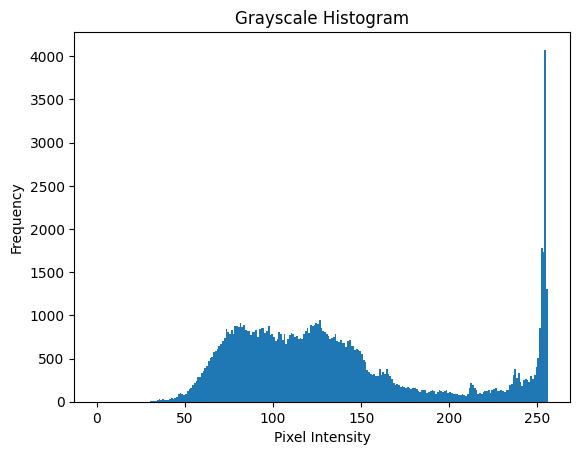

In [10]:
plt.hist(gray.ravel(),256,[0,256])
plt.title("Grayscale Histogram")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_182/1741346978.py:16: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray.ravel(),256,[0,256])


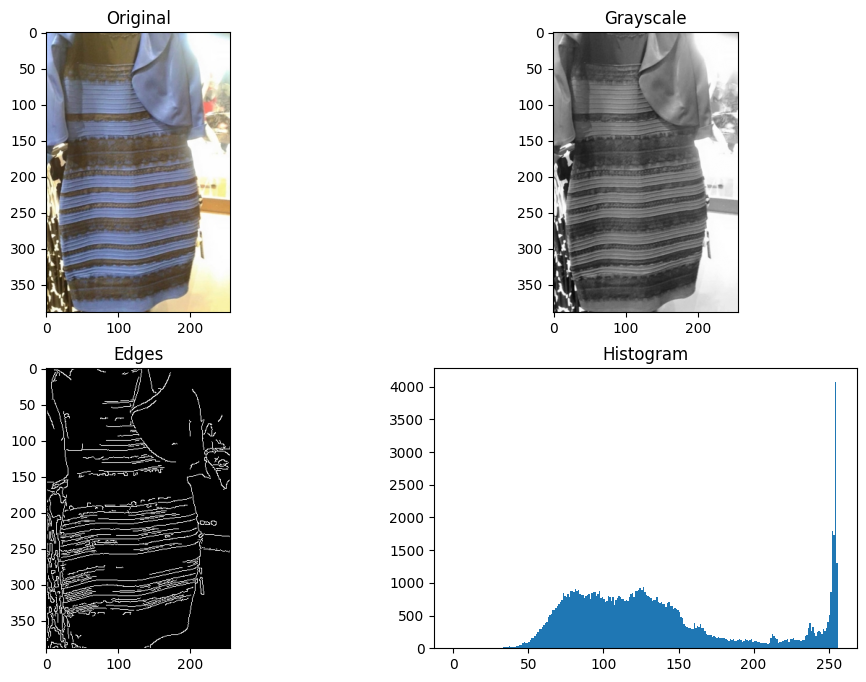

In [11]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title("Original")

plt.subplot(2,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.subplot(2,2,3)
plt.imshow(edges, cmap='gray')
plt.title("Edges")

plt.subplot(2,2,4)
plt.hist(gray.ravel(),256,[0,256])
plt.title("Histogram")

plt.show()